# Exercício 1

Utilizando o método ingênuo gere uma amostra de tamanho $M=1000$ de uma variável geométrica com parâmetro $p$. Compara o gráfico da sua distribuição com a função do numpy. Além disso, compare o que acontece quando você varia o valor $p$

# Exercício 2

Repita o exercício anterior, porém utilizando o método de inversão. Compare o tempo gasto por esse método versus o método ingênuo do item anterior usando a função `time.time` variando o $p$, ou seja, no eixo $y$ coloque o tempo e no eixo $x$ coloque $p$.

# Exercício 3

Gere uma amostra de tamanho $M=1000$ de uma Poisson com parâmetro $\lambda$ usando o método recursivo.  

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [28]:
#Exercício 1
amostra = []
N = 1000
for i in range(N):
    b = []
    p = 0.2
    x = 1
    uniform = np.random.uniform(0,1,size = 1)
    for numero in uniform:
      if numero <= p:
        numero = 1
      else:
        numero = 0
      b.append(numero)
    while b[0] == 0:
      x = x+1
      uniform = np.random.uniform(0,1,size = 1)
      for numero in uniform:
        if numero <= p:
          numero = 1
        else:
          numero = 0
        b[0] = numero
    amostra.append(x)


(array([465., 202., 160.,  72.,  51.,  23.,  15.,   5.,   5.,   2.]),
 array([ 1. ,  3.5,  6. ,  8.5, 11. , 13.5, 16. , 18.5, 21. , 23.5, 26. ]),
 <BarContainer object of 10 artists>)

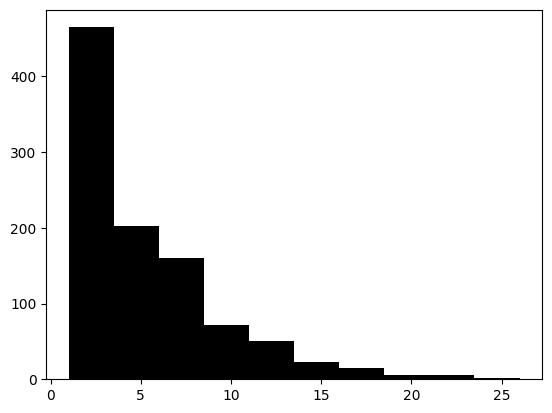

In [29]:
plt.hist(amostra,color = 'Black')


(array([486., 240., 116.,  81.,  37.,  19.,  12.,   5.,   2.,   2.]),
 array([ 1.,  4.,  7., 10., 13., 16., 19., 22., 25., 28., 31.]),
 <BarContainer object of 10 artists>)

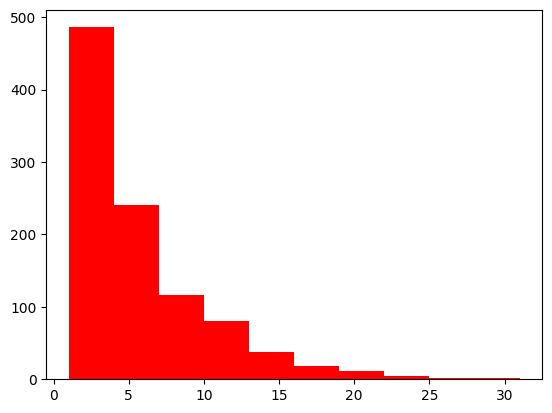

In [30]:
amostra_gerada = np.random.geometric(0.2,1000)
plt.hist(amostra_gerada,color='Red')

Os gráficos gerados pela distribuição do numpy e pela distribuição da amostra gerada são praticamente identicos, demonstrando a veracidade do método

Agora alterando o valor do p para um maior valor (p = 0.8) :

(array([696.,   0., 211.,   0.,  66.,   0.,  16.,   0.,   9.,   2.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

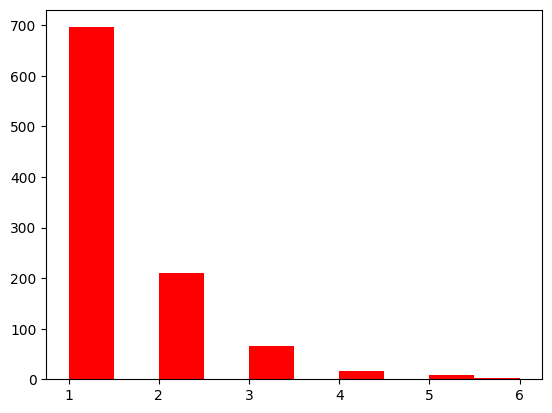

In [31]:
amostra_geradas = np.random.geometric(0.7,1000)
plt.hist(amostra_geradas,color='Red')

O gráfico fica de certa forma degenerado, pois como a probabilidade de sucesso é alta, a chance de obtermos o primeiro sucesso em poucos passos e, assim acabar o experimento, é alta.


In [32]:
#Exercício 2
ps = np.linspace(0.1,0.99,20)
tempos_p = []
for p in ps:
  amostra_esperta = []
  N = 1000
  inicio = time.time()
  for i in range(N):
    u = np.random.uniform()
    num = np.log(1-u)
    dem = np.log(1-p)
    x = np.floor(num/dem) + 1
    amostra_esperta.append(x)
  fim = time.time()
  tempo = fim - inicio
  tempos_p.append(tempo)

In [33]:
pz = np.linspace(0.1,0.99,20)
tempos_pz = []
for j in pz:
  amostra = []
  N = 1000
  inicio = time.time()
  for i in range(N):
    b = []
    x = 1
    uniform = np.random.uniform(0,1,size = 1)
    for numero in uniform:
      if numero <= j:
        numero = 1
      else:
        numero = 0
      b.append(numero)
    while b[0] == 0:
      x = x+1
      uniform = np.random.uniform(0,1,size = 1)
      for numero in uniform:
        if numero <= j:
          numero = 1
        else:
          numero = 0
        b[0] = numero
    amostra.append(x)
  fim = time.time()
  tempos = fim - inicio
  tempos_pz.append(tempos)


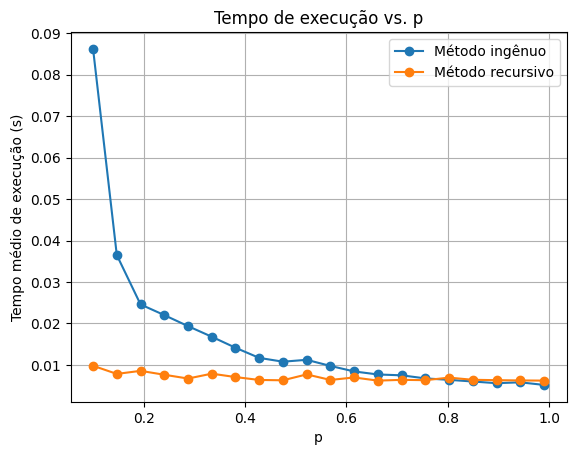

In [34]:
plt.plot(pz, tempos_pz, marker='o', label='Método ingênuo')
plt.plot(ps, tempos_p, marker='o', label='Método recursivo')
plt.xlabel('p')
plt.ylabel('Tempo médio de execução (s)')
plt.title('Tempo de execução vs. p')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
#Exercício 3
amostra_poisson = []
N = 1000
for i in range(N):
  u = np.random.uniform()
  lam = 3
  i = 0
  p = np.exp(-lam)
  F = p

  while u>F:
    i = i+1
    p = p*(lam/i)
    F = F + p

  x = i
  amostra_poisson.append(x)

(array([ 47., 140., 244., 208., 166., 105.,  64.,  18.,   4.,   4.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

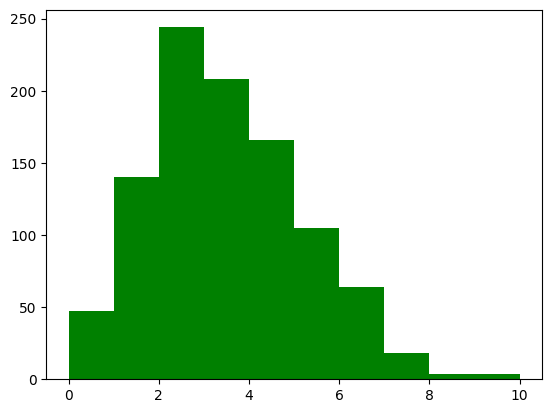

In [36]:
plt.hist(amostra_poisson, color = 'Green')